# Binance Order-Flow MM Proxy + Vectorbt Backtest

Bu notebook BIST OHLCV'de yapmaya calistigimiz "market maker izi" fikrini kriptoda daha dogru veriyle dener.

Yeni ana veri yolu CCXT'dir:

- `ccxt.binance().fetch_ohlcv()` calisiyorsa 5m OHLCV ile volume/CLV proxy feature'lari uretilir.
- `ccxt.binance().fetch_trades()` calisiyorsa taker buy/sell akisi da kullanilir.
- CCXT calismazsa eski public REST/archive fallback'leri denenir.
- 5m mum datasinda alpha "gercek order book" degil proxy'dir; notebook bunu `DATA_MODE` ile acikca yazar.
- Vectorbt backtest win-rate'i tek basina optimize etmez; profit factor, expectancy ve drawdown ile birlikte raporlar.
- Historical full order book yoksa notebook'taki live depth collector ile bugunden veri toplamaya baslanir.


## Metodoloji

OHLCV ile market maker'i direkt gormuyoruz; kriptoda en azindan islemin agresif tarafini gorebiliyoruz. Binance `aggTrades` alaninda `isBuyerMaker=True` ise buyer maker'dir, yani agresif taraf seller/taker kabul edilir. Bundan su proxy'leri uretiyoruz:

- `taker_buy_qty`, `taker_sell_qty`: agresif alis/satis miktari.
- `imbalance`: `(taker_buy - taker_sell) / toplam`.
- `signed_notional_z`: signed flow'un rolling z-score'u.
- `vwap_gap_bps`: fiyat VWAP ustunde/altinda ne kadar ayrismis.
- `volume_ratio`: bar hacmi rolling median hacme gore ne kadar yuksek.
- `regime`: 5m close, EMA ustunde mi ve EMA egimi pozitif/negatif mi.

Signal mantigi:

- **Toxic continuation:** agresif flow fiyatla ayni yone yuksek hacimle geliyor ve 5m trend de ayni yondeyse momentum devamini dener.
- **Exhaustion fade:** agresif flow cok tek tarafli ama fiyat VWAP/Bollinger disindan iceri donuyorsa kisa sureli mean reversion dener.
- **Order book:** historical L2 yoksa mumdan derinlik uydurmuyoruz. Notebook'taki collector ile bugunden itibaren `depth@100ms`/`bookTicker` kaydedilir, sonra event-driven replay'e gecilir.


In [53]:
import os
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/codex_numba_cache")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib_cache")

from pathlib import Path
from datetime import datetime, timezone, timedelta
import hashlib
import hmac
import io
import json
import socket
import ssl
import math
import time
import urllib.parse
import warnings
import zipfile

import numpy as np

try:
    import ccxt
except ImportError:
    ccxt = None
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

try:
    import requests
except ImportError as exc:
    raise ImportError("Bu notebook requests ister. Eski .venv'de var; yoksa `%pip install requests` calistir.") from exc

try:
    import vectorbt as vbt
except Exception as exc:
    raise ImportError(
        "vectorbt import edilemedi. Bu notebook eski proje .venv'i ile acilmali. "
        "Ayrica NUMBA_CACHE_DIR ilk satirda ayarlandi."
    ) from exc

print("pandas", pd.__version__)
print("vectorbt", vbt.__version__)
print("NUMBA_CACHE_DIR", os.environ.get("NUMBA_CACHE_DIR"))


pandas 2.3.3
vectorbt 1.0.0
NUMBA_CACHE_DIR /private/tmp/codex_numba_cache


In [54]:
# ==========
# Ayarlar
# ==========

# Binance REST/archive symbol format'i slashsiz, CCXT format'i slashli.
SYMBOL = "BTCUSDT"
CCXT_SYMBOL = "BTC/USDT"

# Ana yol artik senin son hucrede kullandigin CCXT.
# Secenekler: "ccxt", "rest", "archive", "auto"
SOURCE = "ccxt"

MARKET = "spot"
CCXT_EXCHANGE_ID = "binance"
CCXT_DEFAULT_TYPE = "spot"
CCXT_TIMEFRAME = "5m"
CCXT_PANDAS_FREQ = "5min"
CCXT_LIMIT = 500
CCXT_TRADE_LIMIT = 1000

# Trade varsa microstructure frame; sadece OHLCV varsa backtest frekansi CCXT_PANDAS_FREQ olur.
FEATURE_FRAME = "15s"
ENTRY_FRAME = "1min"
REGIME_FRAME = "5min"
BACKTEST_FREQ = CCXT_PANDAS_FREQ
MIN_FEATURE_ROWS_FOR_BACKTEST = 100
PREFER_TRADE_FLOW_WHEN_ENOUGH_HISTORY = True

REST_LIMIT_TRADES = 1000
REST_LIMIT_KLINES = 1000

FEE = 0.0004
SLIPPAGE = 0.0002
INIT_CASH = 100_000

ARCHIVE_DAYS = [
    (datetime.now(timezone.utc).date() - timedelta(days=2)).isoformat(),
    (datetime.now(timezone.utc).date() - timedelta(days=1)).isoformat(),
]

CACHE_DIR = Path("binance_cache")
SAVE_CACHE = False

print({
    "source": SOURCE,
    "symbol": SYMBOL,
    "ccxt_symbol": CCXT_SYMBOL,
    "ccxt_timeframe": CCXT_TIMEFRAME,
    "feature_frame": FEATURE_FRAME,
    "entry_frame": ENTRY_FRAME,
    "archive_days": ARCHIVE_DAYS,
})


{'source': 'ccxt', 'symbol': 'BTCUSDT', 'ccxt_symbol': 'BTC/USDT', 'ccxt_timeframe': '5m', 'feature_frame': '15s', 'entry_frame': '1min', 'archive_days': ['2026-07-19', '2026-07-20']}


## Veri Katmani

Bu versiyonda notebook senin ekledigin son hucredeki yolu ana kaynak yapar: `ccxt.binance().fetch_ohlcv()`.

Oncelik sirasini bilerek boyle kurdum:

1. CCXT OHLCV: `exchange.fetch_ohlcv("BTC/USDT", timeframe="5m", limit=500)`.
2. CCXT trades: calisiyorsa taker-flow feature'lari icin `exchange.fetch_trades(...)`.
3. Eski public REST: `data-api.binance.vision/api/v3`.
4. Eski public ZIP archive: `data.binance.vision/data/spot/daily/...`.

CCXT sadece OHLCV verirse notebook `DATA_MODE = "ohlcv_proxy"` yazar. Bu modda gercek taker-flow yoktur; signed volume CLV/body proxy ile uretilir. CCXT trades de gelirse `DATA_MODE = "trade_flow"` olur ve agresif alis/satis akisi kullanilir.

`SSLError: WRONG_VERSION_NUMBER` gorursen bu genelde Binance domainine TLS yerine araya HTTP redirect/middlebox cevabi gelmesi demektir. Teshis hucreleri kaldi, ama veri kaynagi artik CCXT-first.


In [55]:
SPOT_REST_BASES = [
    "https://data-api.binance.vision",
    "https://api.binance.com",
    "https://api1.binance.com",
    "https://api2.binance.com",
    "https://api3.binance.com",
    "https://api4.binance.com",
]

ARCHIVE_BASES = [
    "https://data.binance.vision",
    "https://data.binance.com",
]

BINANCE_SESSION = requests.Session()
BINANCE_SESSION.trust_env = False
BINANCE_HEADERS = {
    "User-Agent": "Mozilla/5.0 orderflow-research-notebook/1.0",
    "Accept": "application/json,text/csv,*/*",
}


def proxy_env_vars():
    keys = [
        "HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY", "NO_PROXY",
        "http_proxy", "https_proxy", "all_proxy", "no_proxy",
        "REQUESTS_CA_BUNDLE", "SSL_CERT_FILE",
    ]
    return {k: os.environ[k] for k in keys if os.environ.get(k)}


def clear_proxy_env():
    for k in list(proxy_env_vars()):
        os.environ.pop(k, None)
    BINANCE_SESSION.trust_env = False
    print("Proxy/cert env temizlendi. Kernel restart etmek daha temiz olur.")


def ccxt_to_binance_symbol(symbol):
    return symbol.replace("/", "").replace(":", "").upper()


def binance_to_ccxt_symbol(symbol):
    if "/" in symbol:
        return symbol
    quote_candidates = ["USDT", "FDUSD", "USDC", "BUSD", "BTC", "ETH", "TRY"]
    for quote in quote_candidates:
        if symbol.upper().endswith(quote):
            return symbol[:-len(quote)].upper() + "/" + quote
    return symbol


def make_ccxt_exchange(exchange_id=CCXT_EXCHANGE_ID, default_type=CCXT_DEFAULT_TYPE):
    if ccxt is None:
        raise ImportError("ccxt kurulu degil. Bu .venv'de olmali; yoksa `%pip install ccxt`.")
    klass = getattr(ccxt, exchange_id)
    ex = klass({
        "enableRateLimit": True,
        "timeout": 30000,
        "options": {"defaultType": default_type, "adjustForTimeDifference": True},
    })
    # requests proxy env'inden etkilenmesin.
    try:
        ex.session.trust_env = False
    except Exception:
        pass
    return ex


def load_ccxt_ticker(symbol=CCXT_SYMBOL, exchange=None):
    ex = exchange or make_ccxt_exchange()
    return ex.fetch_ticker(symbol)


def load_ccxt_ohlcv(symbol=CCXT_SYMBOL, timeframe=CCXT_TIMEFRAME, limit=CCXT_LIMIT, exchange=None):
    ex = exchange or make_ccxt_exchange()
    raw = ex.fetch_ohlcv(symbol, timeframe=timeframe, limit=limit)
    df = pd.DataFrame(raw, columns=["open_time", "open", "high", "low", "close", "volume"])
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    freq = pd.Timedelta(CCXT_PANDAS_FREQ)
    df["close_time"] = df["open_time"] + freq
    df["quote_asset_volume"] = df["close"] * df["volume"]
    df["number_of_trades"] = np.nan
    df["taker_buy_base_volume"] = np.nan
    df["taker_buy_quote_volume"] = np.nan
    return df.set_index("open_time").sort_index()


def load_ccxt_trades(symbol=CCXT_SYMBOL, limit=CCXT_TRADE_LIMIT, exchange=None):
    ex = exchange or make_ccxt_exchange()
    raw = ex.fetch_trades(symbol, limit=limit)
    rows = []
    for item in raw:
        info = item.get("info") or {}
        ts = item.get("timestamp") or info.get("T") or info.get("time")
        price = item.get("price") or info.get("p") or info.get("price")
        amount = item.get("amount") or info.get("q") or info.get("qty")
        side = item.get("side")
        is_buyer_maker = info.get("m")
        if isinstance(is_buyer_maker, str):
            is_buyer_maker = is_buyer_maker.lower() == "true"
        if is_buyer_maker is None:
            # CCXT side genelde taker side'dir: buy => buyer taker => buyer maker False.
            if side == "buy":
                is_buyer_maker = False
            elif side == "sell":
                is_buyer_maker = True
        rows.append({
            "timestamp": pd.to_datetime(ts, unit="ms", utc=True),
            "agg_trade_id": item.get("id") or info.get("a"),
            "price": price,
            "quantity": amount,
            "is_buyer_maker": bool(is_buyer_maker) if is_buyer_maker is not None else np.nan,
            "side": side,
            "raw": info,
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    df = df.dropna(subset=["timestamp", "price", "quantity"])
    # is_buyer_maker bilinmiyorsa trade-flow feature guvenilir degil.
    if df["is_buyer_maker"].isna().all():
        print("CCXT trades geldi ama aggressor side/is_buyer_maker yok; OHLCV proxy kullanilacak.")
        return pd.DataFrame()
    df = df.dropna(subset=["is_buyer_maker"])
    return df.set_index("timestamp").sort_index()


def detect_plain_http_middlebox(host, port=443, timeout=4):
    try:
        with socket.create_connection((host, port), timeout=timeout) as sock:
            sock.settimeout(timeout)
            req = f"GET / HTTP/1.0\r\nHost: {host}\r\n\r\n".encode("ascii")
            sock.sendall(req)
            raw = sock.recv(700)
    except Exception as exc:
        return {
            "host": host,
            "middlebox_http": False,
            "guvenli_internet": False,
            "via_middlebox": False,
            "first_line": "",
            "location": "",
            "error": f"{type(exc).__name__}: {str(exc)[:120]}",
        }
    text = raw.decode("latin1", errors="replace")
    first_line = text.splitlines()[0] if text.splitlines() else ""
    location = ""
    for line in text.splitlines():
        if line.lower().startswith("location:"):
            location = line.split(":", 1)[1].strip()
            break
    lower = text.lower()
    return {
        "host": host,
        "middlebox_http": first_line.startswith("HTTP/"),
        "guvenli_internet": "guvenliinternet.turktelekom" in lower,
        "via_middlebox": "middlebox" in lower,
        "first_line": first_line,
        "location": location[:180],
        "error": "",
    }


def diagnose_binance_connectivity(hosts=None, show=True):
    hosts = hosts or ["api.binance.com", "data-api.binance.vision", "data.binance.vision"]
    rows = [detect_plain_http_middlebox(host) for host in hosts]
    df = pd.DataFrame(rows)
    if show:
        try:
            display(df)
        except NameError:
            print(df.to_string(index=False))
        proxy_vars = proxy_env_vars()
        if proxy_vars:
            print("Proxy/cert env var gorundu:", proxy_vars)
        blocked = df[df["guvenli_internet"] | df["via_middlebox"] | df["middlebox_http"]]
        if not blocked.empty:
            print("\nTESHIS: Binance HTTPS baglantisina TLS yerine HTTP redirect/body donuyor.")
            if blocked["guvenli_internet"].any():
                print("Guvenli Internet/Turk Telekom filtresi Binance domainlerini kesiyor gorunuyor.")
            print("CCXT ayni agda calisiyorsa bu teshisi not olarak birak; calismiyorsa ag/VPN/filtre tarafini duzelt.")
    return df


CONNECTIVITY_DIAG = diagnose_binance_connectivity()


def _connectivity_hint():
    try:
        df = CONNECTIVITY_DIAG
        if isinstance(df, pd.DataFrame) and not df.empty:
            blocked = df[df["guvenli_internet"] | df["via_middlebox"] | df["middlebox_http"]]
            if not blocked.empty:
                rows = blocked[["host", "first_line", "location"]].to_dict("records")
                return (
                    "\n\nTESHIS: Binance hostlarina TLS yerine HTTP/middlebox cevabi geliyor. "
                    f"Kanit satirlari: {rows}. "
                    "Turk Telekom Guvenli Internet/aile filtresi, kurumsal filtre veya VPN/proxy engeli olabilir."
                )
    except Exception:
        pass
    return ""


def _request_json(path, params=None, base_urls=None, timeout=20):
    base_urls = base_urls or SPOT_REST_BASES
    errors = []
    for base in base_urls:
        url = base.rstrip("/") + path
        try:
            r = BINANCE_SESSION.get(url, params=params, headers=BINANCE_HEADERS, timeout=timeout)
            text_head = r.text[:500].lower()
            if "guvenliinternet.turktelekom" in text_head:
                raise RuntimeError("Turk Telekom Guvenli Internet redirect yakalandi.")
            if r.status_code == 451:
                raise RuntimeError(f"{base} geo/restriction returned 451: {r.text[:200]}")
            r.raise_for_status()
            return r.json()
        except Exception as exc:
            errors.append(f"{base}: {type(exc).__name__}: {str(exc)[:240]}")
    raise RuntimeError("Butun Binance REST hostlari basarisiz:\n" + "\n".join(errors) + _connectivity_hint())


def _request_bytes(urls, timeout=60):
    if isinstance(urls, str):
        urls = [urls]
    errors = []
    for url in urls:
        try:
            r = BINANCE_SESSION.get(url, headers=BINANCE_HEADERS, timeout=timeout)
            text_head = r.text[:500].lower() if "text" in r.headers.get("content-type", "").lower() else ""
            if "guvenliinternet.turktelekom" in text_head:
                raise RuntimeError("Turk Telekom Guvenli Internet redirect yakalandi.")
            r.raise_for_status()
            return r.content, url
        except Exception as exc:
            errors.append(f"{url}: {type(exc).__name__}: {str(exc)[:220]}")
    raise RuntimeError("Butun archive URL'leri basarisiz:\n" + "\n".join(errors) + _connectivity_hint())


def load_spot_klines_rest(symbol=SYMBOL, interval="1m", limit=1000):
    raw = _request_json("/api/v3/klines", {"symbol": symbol, "interval": interval, "limit": limit})
    cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore",
    ]
    df = pd.DataFrame(raw, columns=cols)
    numeric = [c for c in cols if c not in {"open_time", "close_time"}]
    df[numeric] = df[numeric].apply(pd.to_numeric, errors="coerce")
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)
    return df.set_index("open_time").sort_index()


def load_spot_aggtrades_rest(symbol=SYMBOL, limit=1000, from_id=None, start_time=None, end_time=None):
    params = {"symbol": symbol, "limit": limit}
    if from_id is not None:
        params["fromId"] = int(from_id)
    if start_time is not None:
        params["startTime"] = int(pd.Timestamp(start_time).timestamp() * 1000)
    if end_time is not None:
        params["endTime"] = int(pd.Timestamp(end_time).timestamp() * 1000)
    raw = _request_json("/api/v3/aggTrades", params)
    df = pd.DataFrame(raw)
    if df.empty:
        return df
    df = df.rename(columns={"a": "agg_trade_id", "p": "price", "q": "quantity", "f": "first_trade_id", "l": "last_trade_id", "T": "timestamp", "m": "is_buyer_maker", "M": "is_best_match"})
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    return df.set_index("timestamp").sort_index()


def _download_zip_csv(urls, timeout=60):
    content, ok_url = _request_bytes(urls, timeout=timeout)
    with zipfile.ZipFile(io.BytesIO(content)) as zf:
        names = zf.namelist()
        if not names:
            raise ValueError(f"ZIP bos: {ok_url}")
        with zf.open(names[0]) as fh:
            return pd.read_csv(fh, header=None)


def _archive_urls(path):
    return [base.rstrip("/") + path for base in ARCHIVE_BASES]


def load_klines_archive_day(symbol=SYMBOL, date=None, interval="1m"):
    date = date or (datetime.now(timezone.utc).date() - timedelta(days=1)).isoformat()
    path = f"/data/spot/daily/klines/{symbol}/{interval}/{symbol}-{interval}-{date}.zip"
    raw = _download_zip_csv(_archive_urls(path))
    cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore",
    ]
    raw.columns = cols
    numeric = [c for c in cols if c not in {"open_time", "close_time"}]
    raw[numeric] = raw[numeric].apply(pd.to_numeric, errors="coerce")
    raw["open_time"] = pd.to_datetime(raw["open_time"], unit="ms", utc=True)
    raw["close_time"] = pd.to_datetime(raw["close_time"], unit="ms", utc=True)
    return raw.set_index("open_time").sort_index()


def load_aggtrades_archive_day(symbol=SYMBOL, date=None):
    date = date or (datetime.now(timezone.utc).date() - timedelta(days=1)).isoformat()
    path = f"/data/spot/daily/aggTrades/{symbol}/{symbol}-aggTrades-{date}.zip"
    raw = _download_zip_csv(_archive_urls(path))
    raw.columns = ["agg_trade_id", "price", "quantity", "first_trade_id", "last_trade_id", "timestamp", "is_buyer_maker", "is_best_match"]
    raw["timestamp"] = pd.to_datetime(raw["timestamp"], unit="ms", utc=True)
    raw["price"] = pd.to_numeric(raw["price"], errors="coerce")
    raw["quantity"] = pd.to_numeric(raw["quantity"], errors="coerce")
    return raw.set_index("timestamp").sort_index()


def load_archive_days(loader, days, **kwargs):
    frames = []
    errors = []
    for day in days:
        try:
            frames.append(loader(date=day, **kwargs))
            print(f"ok: {loader.__name__} {day}")
        except Exception as exc:
            errors.append(f"{day}: {type(exc).__name__}: {str(exc)[:260]}")
    if frames:
        return pd.concat(frames).sort_index()
    raise RuntimeError("Archive yuklenemedi:\n" + "\n".join(errors) + _connectivity_hint())


,host,middlebox_http,guvenli_internet,via_middlebox,first_line,location,error
0,api.binance.com,False,False,False,,,TimeoutError: timed out
1,data-api.binance.vision,True,False,False,HTTP/1.1 400 Bad Request,,
2,data.binance.vision,False,False,False,,,TimeoutError: timed out



TESHIS: Binance HTTPS baglantisina TLS yerine HTTP redirect/body donuyor.
CCXT ayni agda calisiyorsa bu teshisi not olarak birak; calismiyorsa ag/VPN/filtre tarafini duzelt.


In [56]:
def load_sample(symbol=SYMBOL, source=SOURCE):
    source = source.lower()
    ccxt_symbol = binance_to_ccxt_symbol(symbol) if "/" not in symbol else symbol
    binance_symbol = ccxt_to_binance_symbol(ccxt_symbol)

    if source == "ccxt":
        ex = make_ccxt_exchange()
        ticker = None
        try:
            ticker = load_ccxt_ticker(symbol=ccxt_symbol, exchange=ex)
            print("CCXT ticker ok:", {k: ticker.get(k) for k in ["bid", "ask", "last", "timestamp"]})
        except Exception as exc:
            print("CCXT ticker cekilemedi, OHLCV deneniyor:", type(exc).__name__, str(exc)[:400])
        klines = load_ccxt_ohlcv(symbol=ccxt_symbol, timeframe=CCXT_TIMEFRAME, limit=CCXT_LIMIT, exchange=ex)
        print("CCXT OHLCV ok:", klines.shape, klines.index.min(), klines.index.max())
        try:
            trades = load_ccxt_trades(symbol=ccxt_symbol, limit=CCXT_TRADE_LIMIT, exchange=ex)
            if not trades.empty:
                print("CCXT trades ok:", trades.shape, trades.index.min(), trades.index.max())
            else:
                print("CCXT trades yok/side eksik; OHLCV proxy moduna gecilecek.")
        except Exception as exc:
            print("CCXT trades cekilemedi; OHLCV proxy moduna gecilecek:", type(exc).__name__, str(exc)[:500])
            trades = pd.DataFrame()
        return trades, klines

    if source == "rest":
        trades = load_spot_aggtrades_rest(symbol=binance_symbol, limit=REST_LIMIT_TRADES)
        klines = load_spot_klines_rest(symbol=binance_symbol, interval="1m", limit=REST_LIMIT_KLINES)
        return trades, klines

    if source == "archive":
        trades = load_archive_days(load_aggtrades_archive_day, ARCHIVE_DAYS, symbol=binance_symbol)
        klines = load_archive_days(load_klines_archive_day, ARCHIVE_DAYS, symbol=binance_symbol, interval="1m")
        return trades, klines

    if source == "auto":
        for candidate in ["ccxt", "rest", "archive"]:
            try:
                print(f"source deneniyor: {candidate}")
                return load_sample(symbol=symbol, source=candidate)
            except Exception as exc:
                print(f"{candidate} basarisiz:", type(exc).__name__, str(exc)[:700])
        raise RuntimeError("ccxt/rest/archive hepsi basarisiz." + _connectivity_hint())

    raise ValueError("source ccxt/rest/archive/auto olmali")


try:
    trades_raw, klines_raw = load_sample(CCXT_SYMBOL, source=SOURCE)
    print("trades", trades_raw.shape, trades_raw.index.min() if not trades_raw.empty else None, trades_raw.index.max() if not trades_raw.empty else None)
    print("klines", klines_raw.shape, klines_raw.index.min() if not klines_raw.empty else None, klines_raw.index.max() if not klines_raw.empty else None)
    display(trades_raw.tail() if not trades_raw.empty else trades_raw)
    display(klines_raw.tail() if not klines_raw.empty else klines_raw)
except Exception as exc:
    trades_raw = pd.DataFrame()
    klines_raw = pd.DataFrame()
    print("Veri cekilemedi. SOURCE='ccxt' calisiyorsa ag/filtre duzeldikten sonra ayni hucre calisir.")
    print(type(exc).__name__)
    print(str(exc)[:1800])


CCXT ticker cekilemedi, OHLCV deneniyor: NetworkError binance GET https://dapi.binance.com/dapi/v1/exchangeInfo
CCXT OHLCV ok: (500, 10) 2026-07-19 20:50:00+00:00 2026-07-21 14:25:00+00:00
CCXT trades ok: (1000, 6) 2026-07-21 14:28:50.463000+00:00 2026-07-21 14:29:48.291000+00:00
trades (1000, 6) 2026-07-21 14:28:50.463000+00:00 2026-07-21 14:29:48.291000+00:00
klines (500, 10) 2026-07-19 20:50:00+00:00 2026-07-21 14:25:00+00:00


,agg_trade_id,price,quantity,is_buyer_maker,side,raw
timestamp,,,,,,
2026-07-21 14:29:47.398000+00:00,4019055691,66737.99,0.00032,False,buy,"{'a': 4019055691, 'p': '66737.99000000', 'q': ..."
2026-07-21 14:29:47.712000+00:00,4019055692,66737.99,0.00076,False,buy,"{'a': 4019055692, 'p': '66737.99000000', 'q': ..."
2026-07-21 14:29:47.879000+00:00,4019055693,66737.99,0.00060,False,buy,"{'a': 4019055693, 'p': '66737.99000000', 'q': ..."
2026-07-21 14:29:48.179000+00:00,4019055694,66737.99,0.02541,False,buy,"{'a': 4019055694, 'p': '66737.99000000', 'q': ..."
2026-07-21 14:29:48.291000+00:00,4019055695,66737.98,0.00747,True,sell,"{'a': 4019055695, 'p': '66737.98000000', 'q': ..."


,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume
open_time,,,,,,,,,,
2026-07-21 14:05:00+00:00,66859.19,66956.15,66792.00,66823.79,260.70755,2026-07-21 14:10:00+00:00,1.742147e+07,NaN,NaN,NaN
2026-07-21 14:10:00+00:00,66823.78,66950.00,66823.78,66944.40,222.78762,2026-07-21 14:15:00+00:00,1.491438e+07,NaN,NaN,NaN
2026-07-21 14:15:00+00:00,66944.40,66944.41,66800.00,66864.01,137.98669,2026-07-21 14:20:00+00:00,9.226343e+06,NaN,NaN,NaN
2026-07-21 14:20:00+00:00,66864.01,66889.80,66663.59,66673.32,137.43881,2026-07-21 14:25:00+00:00,9.163502e+06,NaN,NaN,NaN
2026-07-21 14:25:00+00:00,66673.32,66746.03,66648.27,66737.99,168.41677,2026-07-21 14:30:00+00:00,1.123980e+07,NaN,NaN,NaN


## Feature Uretimi

Iki mod var:

- `trade_flow`: CCXT trades veya REST `aggTrades` geldi ve yeterli tarih kapsiyor. `is_buyer_maker`/side bilgisiyle agresif alis-satis akisi kullanilir.
- `ohlcv_proxy`: 5m OHLCV ile close-location/body/volume proxy feature'lari uretilir.

Onemli duzeltme: CCXT `fetch_trades(limit=1000)` cogu zaman sadece son saniyeleri/dakikayi getirir. Bu data "gelmis" olsa bile backtest icin yeterli tarih degildir. Bu yuzden trade-flow feature satiri `MIN_FEATURE_ROWS_FOR_BACKTEST` altindaysa notebook otomatik 5m OHLCV proxy moduna duser; trade datasini sadece canli akisa dair diagnostik kabul eder.


In [57]:
def rolling_zscore(s, window, min_periods=None):
    min_periods = min_periods or max(5, window // 3)
    mean = s.rolling(window, min_periods=min_periods).mean()
    std = s.rolling(window, min_periods=min_periods).std(ddof=0)
    return (s - mean) / std.replace(0, np.nan)


def prepare_trades(trades):
    if trades.empty:
        return trades.copy()
    df = trades.copy()
    required = {"price", "quantity", "is_buyer_maker"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"trades icinde eksik kolonlar: {missing}")
    df = df.dropna(subset=["price", "quantity", "is_buyer_maker"]).copy()
    df["taker_side"] = np.where(df["is_buyer_maker"].astype(bool), -1, 1)
    df["notional"] = df["price"] * df["quantity"]
    df["signed_qty"] = df["quantity"] * df["taker_side"]
    df["signed_notional"] = df["notional"] * df["taker_side"]
    df["taker_buy_qty"] = np.where(df["taker_side"] > 0, df["quantity"], 0.0)
    df["taker_sell_qty"] = np.where(df["taker_side"] < 0, df["quantity"], 0.0)
    df["taker_buy_notional"] = np.where(df["taker_side"] > 0, df["notional"], 0.0)
    df["taker_sell_notional"] = np.where(df["taker_side"] < 0, df["notional"], 0.0)
    return df


def build_trade_bars(trades, frame=FEATURE_FRAME):
    t = prepare_trades(trades)
    if t.empty:
        return t
    grouped = t.resample(frame)
    bars = pd.DataFrame({
        "open": grouped["price"].first(),
        "high": grouped["price"].max(),
        "low": grouped["price"].min(),
        "close": grouped["price"].last(),
        "volume": grouped["quantity"].sum(),
        "notional": grouped["notional"].sum(),
        "signed_qty": grouped["signed_qty"].sum(),
        "signed_notional": grouped["signed_notional"].sum(),
        "taker_buy_qty": grouped["taker_buy_qty"].sum(),
        "taker_sell_qty": grouped["taker_sell_qty"].sum(),
        "taker_buy_notional": grouped["taker_buy_notional"].sum(),
        "taker_sell_notional": grouped["taker_sell_notional"].sum(),
        "trade_count": grouped["price"].count(),
    })
    bars = bars.dropna(subset=["close"])
    bars["vwap"] = bars["notional"] / bars["volume"].replace(0, np.nan)
    bars["imbalance"] = (bars["taker_buy_qty"] - bars["taker_sell_qty"]) / (bars["volume"].replace(0, np.nan))
    bars["buy_share"] = bars["taker_buy_qty"] / bars["volume"].replace(0, np.nan)
    bars["log_ret"] = np.log(bars["close"]).diff()
    bars["range_bps"] = (bars["high"] - bars["low"]) / bars["close"] * 10_000
    bars["vwap_gap_bps"] = (bars["close"] / bars["vwap"] - 1) * 10_000
    bars["volume_ratio"] = bars["volume"] / bars["volume"].rolling(96, min_periods=20).median().replace(0, np.nan)
    bars["signed_notional_z"] = rolling_zscore(bars["signed_notional"], 96)
    bars["realized_vol"] = bars["log_ret"].rolling(96, min_periods=20).std(ddof=0) * math.sqrt(96)
    bars["bar_seconds"] = pd.Timedelta(frame).total_seconds()
    return bars.replace([np.inf, -np.inf], np.nan)


def _attach_regime(entry, regime_frame=REGIME_FRAME):
    regime = entry["close"].resample(regime_frame).last().dropna().to_frame("regime_close")
    regime["ema_fast"] = regime["regime_close"].ewm(span=12, adjust=False).mean()
    regime["ema_slow"] = regime["regime_close"].ewm(span=36, adjust=False).mean()
    regime["ema_slope"] = regime["ema_fast"].diff()
    regime["regime_up"] = (regime["ema_fast"] > regime["ema_slow"]) & (regime["ema_slope"] > 0)
    regime["regime_down"] = (regime["ema_fast"] < regime["ema_slow"]) & (regime["ema_slope"] < 0)
    regime = regime.reindex(entry.index, method="ffill")
    return entry.join(regime[["ema_fast", "ema_slow", "ema_slope", "regime_up", "regime_down"]])


def build_entry_frame(trade_bars, entry_frame=ENTRY_FRAME, regime_frame=REGIME_FRAME):
    if trade_bars.empty:
        return trade_bars
    g = trade_bars.resample(entry_frame)
    entry = pd.DataFrame({
        "open": g["open"].first(),
        "high": g["high"].max(),
        "low": g["low"].min(),
        "close": g["close"].last(),
        "volume": g["volume"].sum(),
        "notional": g["notional"].sum(),
        "signed_notional": g["signed_notional"].sum(),
        "taker_buy_qty": g["taker_buy_qty"].sum(),
        "taker_sell_qty": g["taker_sell_qty"].sum(),
        "trade_count": g["trade_count"].sum(),
        "vwap": g["vwap"].last(),
        "imbalance": g["imbalance"].mean(),
        "signed_notional_z": g["signed_notional_z"].last(),
        "volume_ratio": g["volume_ratio"].last(),
        "range_bps": g["range_bps"].mean(),
        "vwap_gap_bps": g["vwap_gap_bps"].last(),
    }).dropna(subset=["close"])
    entry["log_ret"] = np.log(entry["close"]).diff()
    entry["atr_bps"] = ((entry["high"] - entry["low"]).rolling(20, min_periods=5).mean() / entry["close"]) * 10_000
    entry["recent_high"] = entry["close"].rolling(20, min_periods=5).max().shift(1)
    entry["recent_low"] = entry["close"].rolling(20, min_periods=5).min().shift(1)
    return _attach_regime(entry, regime_frame=regime_frame).replace([np.inf, -np.inf], np.nan)


def _normalize_ohlcv_columns(klines):
    k = klines.copy()
    rename = {c: c.lower() for c in k.columns}
    k = k.rename(columns=rename)
    if "datetime" in k.columns and not isinstance(k.index, pd.DatetimeIndex):
        k["datetime"] = pd.to_datetime(k["datetime"], utc=True)
        k = k.set_index("datetime")
    if "timestamp" in k.columns and not isinstance(k.index, pd.DatetimeIndex):
        k["timestamp"] = pd.to_datetime(k["timestamp"], unit="ms", utc=True)
        k = k.set_index("timestamp")
    if not isinstance(k.index, pd.DatetimeIndex):
        raise ValueError("OHLCV index datetime olmali veya Timestamp/Datetime kolonu olmali.")
    required = ["open", "high", "low", "close", "volume"]
    missing = [c for c in required if c not in k.columns]
    if missing:
        raise ValueError(f"OHLCV kolonlari eksik: {missing}")
    for col in required:
        k[col] = pd.to_numeric(k[col], errors="coerce")
    return k.sort_index().dropna(subset=required)


def build_ohlcv_proxy_features(klines, regime_frame=REGIME_FRAME):
    k = _normalize_ohlcv_columns(klines)
    if k.empty:
        return k
    f = k[["open", "high", "low", "close", "volume"]].copy()
    f["typical_price"] = (f["high"] + f["low"] + f["close"]) / 3
    f["notional"] = f["typical_price"] * f["volume"]
    rolling_notional = f["notional"].rolling(20, min_periods=5).sum()
    rolling_volume = f["volume"].rolling(20, min_periods=5).sum()
    f["vwap"] = rolling_notional / rolling_volume.replace(0, np.nan)

    price_range = (f["high"] - f["low"]).replace(0, np.nan)
    clv = ((f["close"] - f["low"]) - (f["high"] - f["close"])) / price_range
    body = (f["close"] - f["open"]) / price_range
    signed_pressure = (0.7 * clv.fillna(0) + 0.3 * body.fillna(0)).clip(-1, 1)

    f["signed_qty"] = f["volume"] * signed_pressure
    f["signed_notional"] = f["signed_qty"] * f["typical_price"]
    f["taker_buy_qty"] = ((f["volume"] + f["signed_qty"]) / 2).clip(lower=0)
    f["taker_sell_qty"] = ((f["volume"] - f["signed_qty"]) / 2).clip(lower=0)
    f["imbalance"] = f["signed_qty"] / f["volume"].replace(0, np.nan)
    f["buy_share"] = f["taker_buy_qty"] / f["volume"].replace(0, np.nan)
    f["log_ret"] = np.log(f["close"]).diff()
    f["range_bps"] = (f["high"] - f["low"]) / f["close"] * 10_000
    f["vwap_gap_bps"] = (f["close"] / f["vwap"] - 1) * 10_000
    f["volume_ratio"] = f["volume"] / f["volume"].rolling(48, min_periods=10).median().replace(0, np.nan)
    f["signed_notional_z"] = rolling_zscore(f["signed_notional"], 48)
    f["atr_bps"] = ((f["high"] - f["low"]).rolling(20, min_periods=5).mean() / f["close"]) * 10_000
    f["recent_high"] = f["close"].rolling(20, min_periods=5).max().shift(1)
    f["recent_low"] = f["close"].rolling(20, min_periods=5).min().shift(1)
    f["trade_count"] = np.nan
    return _attach_regime(f, regime_frame=regime_frame).replace([np.inf, -np.inf], np.nan)


trade_bars = build_trade_bars(trades_raw, FEATURE_FRAME) if not trades_raw.empty else pd.DataFrame()
trade_features = build_entry_frame(trade_bars, ENTRY_FRAME, REGIME_FRAME) if not trade_bars.empty else pd.DataFrame()
ohlcv_features = build_ohlcv_proxy_features(klines_raw, REGIME_FRAME) if not klines_raw.empty else pd.DataFrame()

trade_flow_rows = len(trade_features)
ohlcv_rows = len(ohlcv_features)
trade_flow_coverage_ok = trade_flow_rows >= MIN_FEATURE_ROWS_FOR_BACKTEST

if (
    PREFER_TRADE_FLOW_WHEN_ENOUGH_HISTORY
    and trade_flow_coverage_ok
):
    DATA_MODE = "trade_flow"
    features = trade_features
    BACKTEST_FREQ = ENTRY_FRAME
elif not ohlcv_features.empty:
    DATA_MODE = "ohlcv_proxy"
    features = ohlcv_features
    BACKTEST_FREQ = CCXT_PANDAS_FREQ
    if trade_flow_rows:
        print(
            f"Trade-flow geldi ama backtest icin kisa: {trade_flow_rows} satir. "
            f"OHLCV proxy kullaniliyor: {ohlcv_rows} satir."
        )
elif not trade_features.empty:
    DATA_MODE = "trade_flow_short_sample"
    features = trade_features
    BACKTEST_FREQ = ENTRY_FRAME
    print(
        f"UYARI: Sadece {trade_flow_rows} trade-flow feature satiri var. "
        "Bu backtest icin yeterli degil; daha uzun aggTrades/archive/live collector gerekli."
    )
else:
    DATA_MODE = "no_data"
    features = pd.DataFrame()

print("DATA_MODE", DATA_MODE)
print("BACKTEST_FREQ", BACKTEST_FREQ)
print("trade_bars", trade_bars.shape)
print("trade_features", trade_features.shape)
print("ohlcv_features", ohlcv_features.shape)
print("features", features.shape)
display(features.tail(10) if not features.empty else features)


Trade-flow geldi ama backtest icin kisa: 2 satir. OHLCV proxy kullaniliyor: 500 satir.
DATA_MODE ohlcv_proxy
BACKTEST_FREQ 5min
trade_bars (5, 23)
trade_features (2, 25)
ohlcv_features (500, 28)
features (500, 28)


,open,high,low,close,volume,typical_price,notional,vwap,signed_qty,signed_notional,taker_buy_qty,taker_sell_qty,imbalance,buy_share,log_ret,range_bps,vwap_gap_bps,volume_ratio,signed_notional_z,atr_bps,recent_high,recent_low,trade_count,ema_fast,ema_slow,ema_slope,regime_up,regime_down
open_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-07-21 13:40:00+00:00,66414.00,66418.00,66315.62,66367.99,125.11889,66367.203333,8.303791e+06,66480.081752,-14.849772,-9.855378e+05,55.134559,69.984331,-0.118685,0.440657,-0.000693,15.426111,-16.860953,1.924086,-0.256226,14.867484,66630.34,66275.99,NaN,66475.865104,66417.736672,-19.613655,False,False
2026-07-21 13:45:00+00:00,66367.99,66666.57,66344.00,66653.99,182.41745,66554.853333,1.214077e+07,66491.824191,166.253399,1.106497e+07,174.335424,8.082026,0.911390,0.955695,0.004300,48.394702,24.388834,2.620096,2.476514,16.266468,66630.34,66367.99,NaN,66503.268934,66430.507122,27.403830,True,False
2026-07-21 13:50:00+00:00,66654.00,66759.77,66600.00,66741.57,207.45116,66700.446667,1.383709e+07,66519.167889,146.242875,9.754465e+06,176.847018,30.604142,0.704951,0.852475,0.001313,23.938604,33.434289,2.839046,2.047192,16.842726,66653.99,66367.99,NaN,66539.930637,66447.321331,36.661702,True,False
2026-07-21 13:55:00+00:00,66741.58,66810.97,66731.32,66786.00,173.02888,66776.096667,1.155419e+07,66545.060645,74.127614,4.949953e+06,123.578247,49.450633,0.428412,0.714206,0.000665,11.926152,36.206948,2.277895,0.957234,16.569116,66741.57,66367.99,NaN,66577.787462,66465.628286,37.856825,True,False
2026-07-21 14:00:00+00:00,66786.00,66859.62,66740.43,66859.19,227.20631,66819.746667,1.518187e+07,66582.198673,199.752452,1.334741e+07,213.479381,13.726929,0.879168,0.939584,0.001095,17.827018,41.601409,2.924144,2.531937,16.765010,66786.00,66367.99,NaN,66621.080160,66486.901893,43.292698,True,False
2026-07-21 14:05:00+00:00,66859.19,66956.15,66792.00,66823.79,260.70755,66857.313333,1.743021e+07,66620.243035,-128.676607,-8.602972e+06,66.015472,194.692078,-0.493567,0.253217,-0.000530,24.564605,30.553321,3.343945,-1.802305,17.639826,66859.19,66367.99,NaN,66652.266289,66505.112061,31.186129,True,False
2026-07-21 14:10:00+00:00,66823.78,66950.00,66823.78,66944.40,222.78762,66906.060000,1.490584e+07,66654.733097,205.984117,1.378159e+07,214.385869,8.401751,0.924576,0.962288,0.001803,18.854452,43.457815,2.724227,2.358161,17.573688,66859.19,66367.99,NaN,66697.209937,66528.857355,44.943648,True,False
2026-07-21 14:15:00+00:00,66944.40,66944.41,66800.00,66864.01,137.98669,66869.473333,9.227097e+06,66670.207521,-34.006968,-2.274028e+06,51.989861,85.996829,-0.246451,0.376774,-0.001202,21.597568,29.068828,1.614678,-0.569006,17.425144,66944.40,66367.99,NaN,66722.871485,66546.973714,25.661548,True,False
2026-07-21 14:20:00+00:00,66864.01,66889.80,66663.59,66673.32,137.43881,66742.236667,9.172974e+06,66676.488293,-122.688183,-8.188484e+06,7.375314,130.063496,-0.892675,0.053663,-0.002856,33.928114,-0.475174,1.608266,-1.568557,18.213282,66944.40,66367.99,NaN,66715.248180,66553.803243,-7.623305,False,False


## Sinyaller

Sinyal isimleri ayni kaliyor ama veri moduna gore anlamlari degisir:

- `trade_flow`: imbalance gercek agresif alis/satis akisi.
- `ohlcv_proxy`: imbalance 5m mumun close-location/body/volume proxy'si.

Bu yuzden `ohlcv_proxy` modunda sonuc daha temkinli okunmali. 5m OHLCV ile market maker'i takip etmiyoruz; sadece fiyat-hacim izlerinden trade edilebilir bir ritim ariyoruz.


In [58]:
SIGNAL_PARAM_KEYS = {
    "imb_thr", "z_thr", "vol_ratio_thr", "break_lookback",
    "hold_bars", "fade_z_thr", "fade_vwap_bps",
}


def signal_only_params(params):
    params = params or {}
    return {k: params[k] for k in SIGNAL_PARAM_KEYS if k in params}


def make_time_exit(entries, hold_bars):
    return entries.shift(int(hold_bars)).fillna(False).astype(bool)


def build_signals(
    f,
    imb_thr=0.18,
    z_thr=1.0,
    vol_ratio_thr=1.15,
    break_lookback=20,
    hold_bars=8,
    fade_z_thr=2.0,
    fade_vwap_bps=4.0,
):
    if f.empty:
        idx = f.index
        empty = pd.Series(False, index=idx)
        return empty, empty, empty, empty

    recent_high = f["close"].rolling(break_lookback, min_periods=max(3, break_lookback // 3)).max().shift(1)
    recent_low = f["close"].rolling(break_lookback, min_periods=max(3, break_lookback // 3)).min().shift(1)

    long_cont = (
        f["regime_up"].fillna(False)
        & (f["imbalance"] > imb_thr)
        & (f["signed_notional_z"] > z_thr)
        & (f["volume_ratio"] > vol_ratio_thr)
        & (f["close"] > recent_high)
        & (f["vwap_gap_bps"] > 0)
    )

    short_cont = (
        f["regime_down"].fillna(False)
        & (f["imbalance"] < -imb_thr)
        & (f["signed_notional_z"] < -z_thr)
        & (f["volume_ratio"] > vol_ratio_thr)
        & (f["close"] < recent_low)
        & (f["vwap_gap_bps"] < 0)
    )

    # Exhaustion: agresif flow cok tek tarafli, ama fiyat VWAP tarafina geri sarkiyor.
    long_fade = (
        (f["signed_notional_z"] < -fade_z_thr)
        & (f["imbalance"] < -imb_thr)
        & (f["vwap_gap_bps"] > -fade_vwap_bps)
        & (f["close"] > f["low"].rolling(5, min_periods=2).min().shift(1))
    )
    short_fade = (
        (f["signed_notional_z"] > fade_z_thr)
        & (f["imbalance"] > imb_thr)
        & (f["vwap_gap_bps"] < fade_vwap_bps)
        & (f["close"] < f["high"].rolling(5, min_periods=2).max().shift(1))
    )

    entries = (long_cont | long_fade).fillna(False)
    short_entries = (short_cont | short_fade).fillna(False)
    exits = make_time_exit(entries, hold_bars) | short_entries
    short_exits = make_time_exit(short_entries, hold_bars) | entries
    return entries.astype(bool), exits.astype(bool), short_entries.astype(bool), short_exits.astype(bool)


def trade_metrics(pf):
    trades = pf.trades.records_readable
    total_return = float(pf.total_return())
    max_dd = float(pf.max_drawdown())
    if trades.empty:
        return {
            "trades": 0,
            "win_rate": np.nan,
            "total_return": total_return,
            "max_drawdown": max_dd,
            "profit_factor": np.nan,
            "expectancy": np.nan,
            "avg_win": np.nan,
            "avg_loss": np.nan,
            "payoff": np.nan,
        }
    pnl_col = "PnL" if "PnL" in trades.columns else "Return"
    pnl = pd.to_numeric(trades[pnl_col], errors="coerce").dropna()
    wins = pnl[pnl > 0]
    losses = pnl[pnl < 0]
    gross_win = wins.sum()
    gross_loss = losses.abs().sum()
    profit_factor = gross_win / gross_loss if gross_loss > 0 else np.inf
    avg_win = wins.mean() if len(wins) else 0.0
    avg_loss = losses.mean() if len(losses) else 0.0
    payoff = abs(avg_win / avg_loss) if avg_loss < 0 else np.inf
    return {
        "trades": int(len(pnl)),
        "win_rate": float((pnl > 0).mean()),
        "total_return": total_return,
        "max_drawdown": max_dd,
        "profit_factor": float(profit_factor),
        "expectancy": float(pnl.mean()),
        "avg_win": float(avg_win),
        "avg_loss": float(avg_loss),
        "payoff": float(payoff),
    }


def run_vectorbt(f, params=None, direction="both"):
    params = params or {}
    entries, exits, short_entries, short_exits = build_signals(f, **signal_only_params(params))
    close = f["close"].astype(float)
    sl_stop = params.get("sl_stop", 0.004)
    tp_stop = params.get("tp_stop", 0.002)
    if direction == "long_only":
        short_entries = pd.Series(False, index=f.index)
        short_exits = pd.Series(False, index=f.index)
    elif direction == "short_only":
        entries = pd.Series(False, index=f.index)
        exits = pd.Series(False, index=f.index)

    pf = vbt.Portfolio.from_signals(
        close,
        entries=entries,
        exits=exits,
        short_entries=short_entries,
        short_exits=short_exits,
        init_cash=INIT_CASH,
        fees=FEE,
        slippage=SLIPPAGE,
        sl_stop=sl_stop,
        tp_stop=tp_stop,
        freq=BACKTEST_FREQ,
    )
    metrics = trade_metrics(pf)
    metrics.update({"entries": int(entries.sum()), "short_entries": int(short_entries.sum()), "data_mode": DATA_MODE, "freq": BACKTEST_FREQ})
    return pf, metrics


base_params = {
    "imb_thr": 0.18,
    "z_thr": 1.0,
    "vol_ratio_thr": 1.15,
    "break_lookback": 20,
    "hold_bars": 8,
    "fade_z_thr": 2.0,
    "fade_vwap_bps": 4.0,
    "sl_stop": 0.004,
    "tp_stop": 0.002,
}

if not features.empty:
    pf_base, metrics_base = run_vectorbt(features.dropna(subset=["close"]), base_params)
    display(pd.Series(metrics_base).to_frame("base"))
    display(pf_base.trades.records_readable.tail())
else:
    print("Feature yok; once veri hucrelerini calistir.")


,base
trades,22
win_rate,0.5
total_return,-0.01282
max_drawdown,-0.015206
profit_factor,0.622339
expectancy,-58.27311
avg_win,192.054151
avg_loss,-308.600371
payoff,0.622339
entries,39


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id
17,17,0,1.500520,2026-07-21 06:40:00+00:00,65976.192600,39.599436,2026-07-21 07:45:00+00:00,66194.920000,39.730718,248.874661,0.002514,Long,Closed,17
18,18,0,1.494510,2026-07-21 10:20:00+00:00,66407.958936,39.698946,2026-07-21 11:00:00+00:00,66167.843784,39.555404,-438.108867,-0.004414,Long,Closed,18
19,19,0,1.486599,2026-07-21 12:15:00+00:00,66466.770696,39.523772,2026-07-21 12:35:00+00:00,66630.340000,39.621037,164.017145,0.001660,Long,Closed,19
20,20,0,1.484586,2026-07-21 13:45:00+00:00,66667.320798,39.589353,2026-07-21 14:00:00+00:00,66859.190000,39.703292,205.553719,0.002077,Long,Closed,20
21,21,0,1.481215,2026-07-21 14:10:00+00:00,66957.788880,39.671542,2026-07-21 14:20:00+00:00,66673.320000,39.502998,-500.533996,-0.005047,Long,Closed,21


## Train/Test Grid

Burada amac "win rate'i 80 yapalim" diye buyuk stop/kucuk take-profit hilesine dusmemek. O yuzden siralama:

1. Test trade sayisi makul mu?
2. Test expectancy pozitif mi?
3. Profit factor 1 ustu mu?
4. Drawdown kabul edilebilir mi?
5. Win rate yuksekse, avg loss avg win'i ezmiyor mu?

Yani 80% win rate ancak profit factor ve expectancy bozulmuyorsa degerli.


In [59]:
from itertools import product


def split_train_test(f, train_frac=0.7):
    n = len(f)
    cut = max(1, int(n * train_frac))
    return f.iloc[:cut].copy(), f.iloc[cut:].copy()


def evaluate_grid(f, min_test_trades=5, direction="both"):
    f = f.dropna(subset=["close"]).copy()
    if len(f) < 200:
        print("Grid icin veri az; archive gunlerini artirmak daha mantikli.")
    train, test = split_train_test(f)

    grid = []
    for imb_thr, z_thr, vol_thr, hold_bars, sl_stop, tp_stop in product(
        [0.12, 0.18, 0.25, 0.35],
        [0.5, 1.0, 1.5, 2.0],
        [1.0, 1.15, 1.35],
        [4, 8, 15, 30],
        [0.0025, 0.004, 0.0075],
        [0.0015, 0.0025, 0.004],
    ):
        params = {
            "imb_thr": imb_thr,
            "z_thr": z_thr,
            "vol_ratio_thr": vol_thr,
            "break_lookback": 20,
            "hold_bars": hold_bars,
            "fade_z_thr": max(1.5, z_thr + 0.75),
            "fade_vwap_bps": 4.0,
            "sl_stop": sl_stop,
            "tp_stop": tp_stop,
        }
        try:
            _, m_train = run_vectorbt(train, params, direction=direction)
            _, m_test = run_vectorbt(test, params, direction=direction)
        except Exception as exc:
            continue
        row = {**params}
        row.update({f"train_{k}": v for k, v in m_train.items()})
        row.update({f"test_{k}": v for k, v in m_test.items()})
        grid.append(row)

    res = pd.DataFrame(grid)
    if res.empty:
        return res
    res["test_win_rate_pct"] = res["test_win_rate"] * 100
    res["train_win_rate_pct"] = res["train_win_rate"] * 100
    res["score"] = (
        res["test_expectancy"].fillna(-np.inf).rank(pct=True)
        + res["test_profit_factor"].replace(np.inf, 10).fillna(0).rank(pct=True)
        + res["test_total_return"].fillna(-np.inf).rank(pct=True)
        - res["test_max_drawdown"].fillna(1).rank(pct=True)
    )
    res["high_wr_but_bad_expectancy"] = (res["test_win_rate"] >= 0.80) & (res["test_expectancy"] <= 0)
    res = res.sort_values(["score", "test_expectancy", "test_profit_factor"], ascending=False)
    if min_test_trades:
        res = res[res["test_trades"] >= min_test_trades]
    return res


if not features.empty:
    grid_results = evaluate_grid(features, min_test_trades=3, direction="both")
    display(grid_results.head(20))
    if not grid_results.empty:
        best_params = grid_results.iloc[0][list(base_params.keys())].to_dict()
        best_params["hold_bars"] = int(best_params["hold_bars"])
        best_params["break_lookback"] = int(best_params["break_lookback"])
        pf_best, best_metrics = run_vectorbt(features.dropna(subset=["close"]), best_params)
        print("best_params", best_params)
        display(pd.Series(best_metrics).to_frame("full_sample_best"))
        display(grid_results[grid_results["test_win_rate"] >= 0.80].head(10))
    else:
        print("Grid bos veya trade sayisi yetersiz. Daha uzun archive sample kullan.")
else:
    grid_results = pd.DataFrame()
    print("Feature yok; once veri hucrelerini calistir.")


,imb_thr,z_thr,vol_ratio_thr,break_lookback,hold_bars,fade_z_thr,fade_vwap_bps,sl_stop,tp_stop,train_trades,train_win_rate,train_total_return,train_max_drawdown,train_profit_factor,train_expectancy,train_avg_win,train_avg_loss,train_payoff,train_entries,train_short_entries,train_data_mode,train_freq,test_trades,test_win_rate,test_total_return,test_max_drawdown,test_profit_factor,test_expectancy,test_avg_win,test_avg_loss,test_payoff,test_entries,test_short_entries,test_data_mode,test_freq,test_win_rate_pct,train_win_rate_pct,score,high_wr_but_bad_expectancy
1399,0.35,0.5,1.35,20,30,1.50,4.0,0.0040,0.0025,17,0.647059,0.005131,-0.009464,1.241713,30.184917,239.644622,-353.824543,0.677298,22,12,ohlcv_proxy,5min,9,0.555556,0.005363,-0.007464,1.812677,59.594106,239.264498,-164.993885,1.450142,25,1,ohlcv_proxy,5min,55.555556,64.705882,2.393519,False
1402,0.35,0.5,1.35,20,30,1.50,4.0,0.0075,0.0025,17,0.647059,0.009724,-0.009464,1.582101,57.197118,240.251645,-278.402849,0.862964,22,12,ohlcv_proxy,5min,9,0.555556,0.005363,-0.007464,1.812677,59.594106,239.264498,-164.993885,1.450142,25,1,ohlcv_proxy,5min,55.555556,64.705882,2.393519,False
1435,0.35,1.0,1.00,20,30,1.75,4.0,0.0040,0.0025,14,0.642857,0.004304,-0.008638,1.230426,30.744482,255.374080,-373.588796,0.683570,17,11,ohlcv_proxy,5min,9,0.555556,0.005363,-0.007464,1.812677,59.594106,239.264498,-164.993885,1.450142,23,1,ohlcv_proxy,5min,55.555556,64.285714,2.393519,False
1438,0.35,1.0,1.00,20,30,1.75,4.0,0.0075,0.0025,14,0.642857,0.008502,-0.008416,1.584702,60.729227,256.033095,-290.817736,0.880390,17,11,ohlcv_proxy,5min,9,0.555556,0.005363,-0.007464,1.812677,59.594106,239.264498,-164.993885,1.450142,23,1,ohlcv_proxy,5min,55.555556,64.285714,2.393519,False
1471,0.35,1.0,1.15,20,30,1.75,4.0,0.0040,0.0025,14,0.642857,0.004304,-0.008638,1.230426,30.744482,255.374080,-373.588796,0.683570,17,11,ohlcv_proxy,5min,9,0.555556,0.005363,-0.007464,1.812677,59.594106,239.264498,-164.993885,1.450142,23,1,ohlcv_proxy,5min,55.555556,64.285714,2.393519,False
1474,0.35,1.0,1.15,20,30,1.75,4.0,0.0075,0.0025,14,0.642857,0.008502,-0.008416,1.584702,60.729227,256.033095,-290.817736,0.880390,17,11,ohlcv_proxy,5min,9,0.555556,0.005363,-0.007464,1.812677,59.594106,239.264498,-164.993885,1.450142,23,1,ohlcv_proxy,5min,55.555556,64.285714,2.393519,False
1507,0.35,1.0,1.35,20,30,1.75,4.0,0.0040,0.0025,14,0.642857,0.004304,-0.008638,1.230426,30.744482,255.374080,-373.588796,0.683570,17,10,ohlcv_proxy,5min,9,0.555556,0.005363,-0.007464,1.812677,59.594106,239.264498,-164.993885,1.450142,22,1,ohlcv_proxy,5min,55.555556,64.285714,2.393519,False
1510,0.35,1.0,1.35,20,30,1.75,4.0,0.0075,0.0025,14,0.642857,0.008502,-0.008416,1.584702,60.729227,256.033095,-290.817736,0.880390,17,10,ohlcv_proxy,5min,9,0.555556,0.005363,-0.007464,1.812677,59.594106,239.264498,-164.993885,1.450142,22,1,ohlcv_proxy,5min,55.555556,64.285714,2.393519,False
104,0.12,0.5,1.35,20,30,1.50,4.0,0.0040,0.0040,14,0.500000,0.006814,-0.011923,1.333470,48.674656,389.277127,-291.927814,1.333470,23,15,ohlcv_proxy,5min,6,0.666667,0.006852,-0.005551,4.345516,114.199563,222.502008,-102.405327,2.172758,28,1,ohlcv_proxy,5min,66.666667,50.000000,2.331597,False
107,0.12,0.5,1.35,20,30,1.50,4.0,0.0075,0.0040,15,0.466667,0.004453,-0.014240,1.195630,29.686892,388.794445,-284.532216,1.366434,23,15,ohlcv_proxy,5min,6,0.666667,0.006852,-0.005551,4.345516,114.199563,222.502008,-102.405327,2.172758,28,1,ohlcv_proxy,5min,66.666667,46.666667,2.331597,False


best_params {'imb_thr': 0.35, 'z_thr': 0.5, 'vol_ratio_thr': 1.35, 'break_lookback': 20, 'hold_bars': 30, 'fade_z_thr': 1.5, 'fade_vwap_bps': 4.0, 'sl_stop': 0.004, 'tp_stop': 0.0025}


,full_sample_best
trades,26
win_rate,0.615385
total_return,0.010769
max_drawdown,-0.009464
profit_factor,1.386482
expectancy,41.420092
avg_win,241.462114
avg_loss,-278.647143
payoff,0.866552
entries,47


,imb_thr,z_thr,vol_ratio_thr,break_lookback,hold_bars,fade_z_thr,fade_vwap_bps,sl_stop,tp_stop,train_trades,train_win_rate,train_total_return,train_max_drawdown,train_profit_factor,train_expectancy,train_avg_win,train_avg_loss,train_payoff,train_entries,train_short_entries,train_data_mode,train_freq,test_trades,test_win_rate,test_total_return,test_max_drawdown,test_profit_factor,test_expectancy,test_avg_win,test_avg_loss,test_payoff,test_entries,test_short_entries,test_data_mode,test_freq,test_win_rate_pct,train_win_rate_pct,score,high_wr_but_bad_expectancy


## Diagnostik Plotlar

Bu bolum backtest sonucunu gorsel olarak kontrol eder:

- Fiyat ustunde long/short entry marker'lari.
- Equity curve ve drawdown.
- Imbalance, signed flow z-score, volume ratio ve VWAP gap.
- Trade PnL histogrami.
- Grid calistiysa win-rate / expectancy scatter ve parametre heatmap'i.

Plotlar guzel ciksa bile alpha kaniti degil; asil filtre test expectancy, profit factor, drawdown ve out-of-sample davranistir.


,close,imbalance,signed_notional_z,volume_ratio,vwap_gap_bps,atr_bps
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,65747.026960,0.044915,0.037642,1.349476,6.270967,12.000686
std,495.774411,0.640506,1.060066,0.916572,20.497754,2.419570
min,65078.000000,-1.000000,-4.063371,0.259503,-59.411348,7.200913
25%,65326.002500,-0.512296,-0.604296,0.701900,-4.349622,9.895045
50%,65565.965000,0.092526,-0.027020,1.075403,8.292999,11.925311
75%,66232.855000,0.658106,0.642489,1.738855,21.580309,14.011887
max,66944.400000,1.000000,3.552024,5.535482,43.457815,18.418595


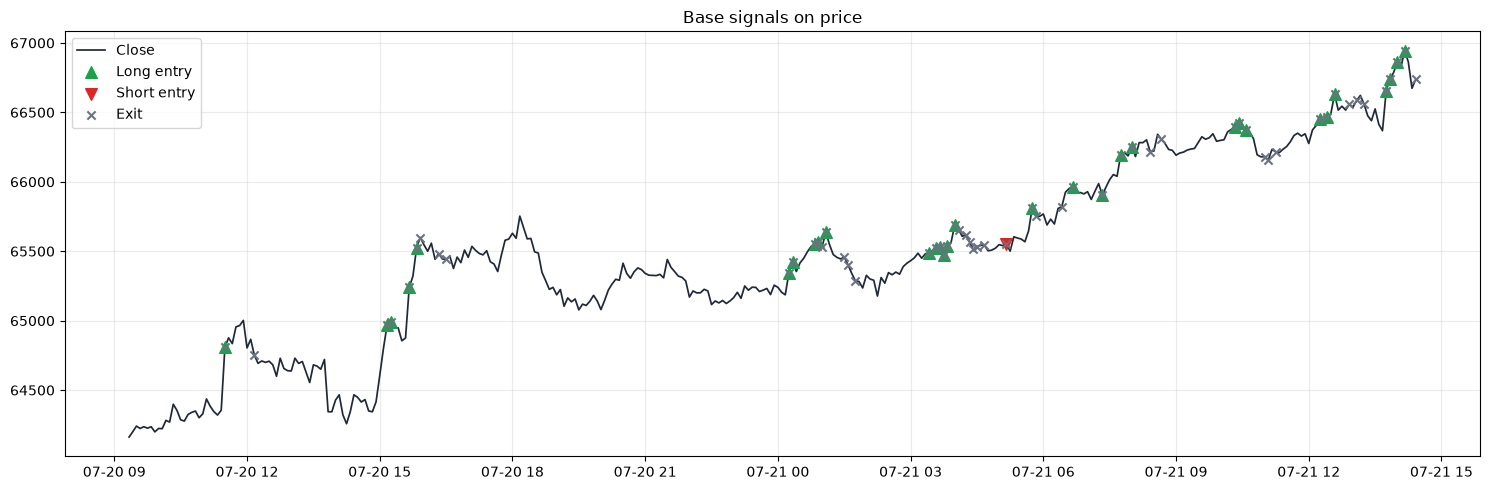

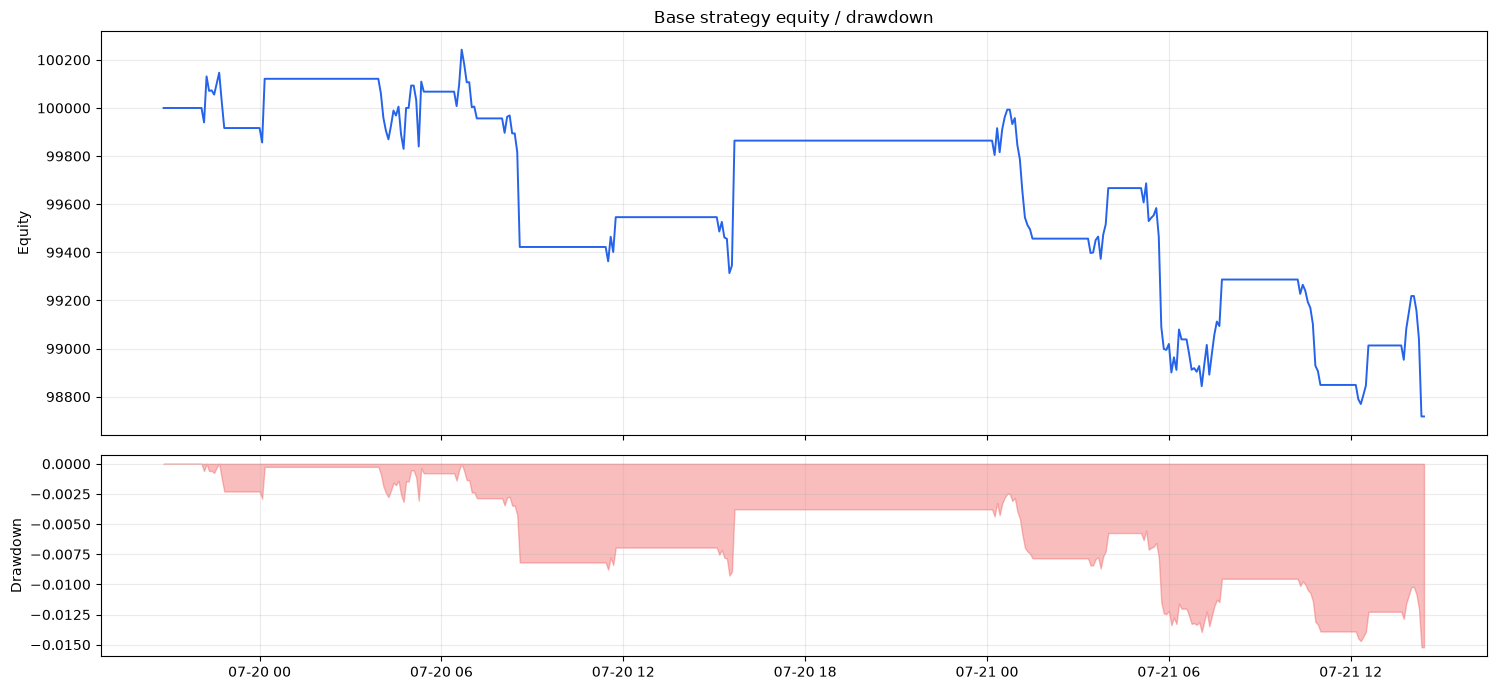

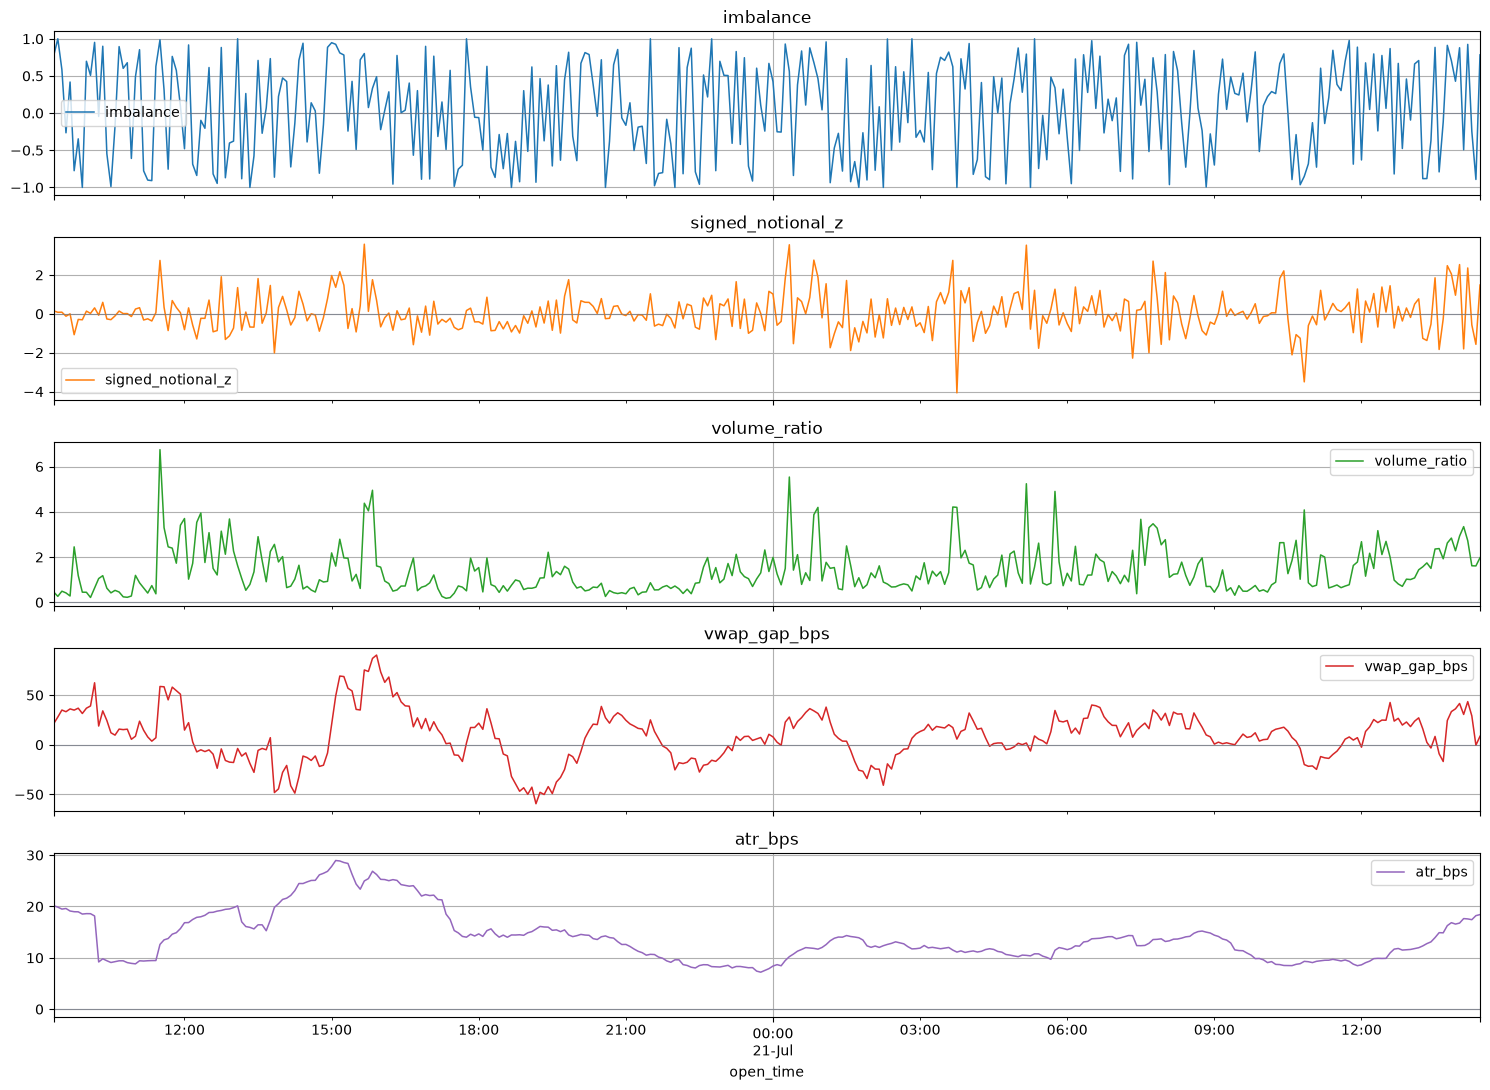

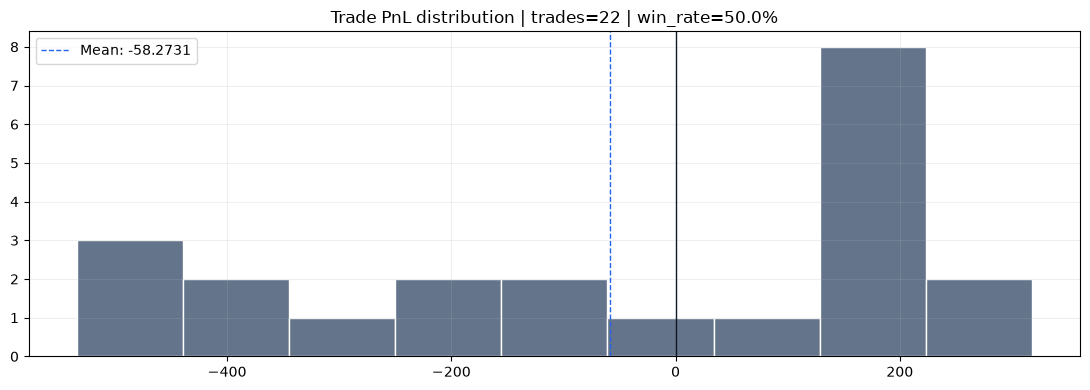

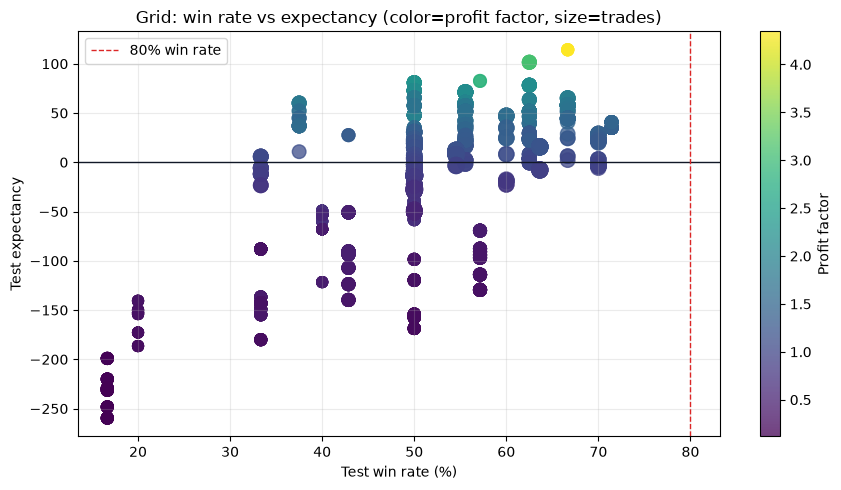

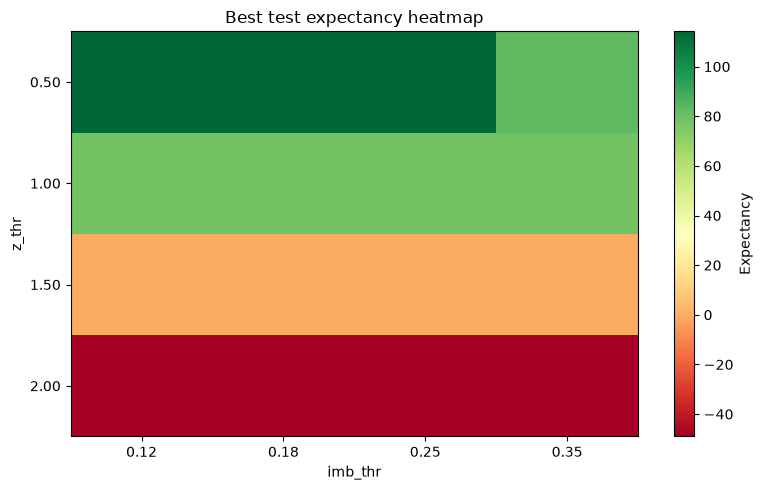

In [60]:
import matplotlib.pyplot as plt


def _pnl_series_from_pf(pf):
    trades = pf.trades.records_readable
    if trades.empty:
        return pd.Series(dtype=float), trades
    pnl_col = "PnL" if "PnL" in trades.columns else ("Return" if "Return" in trades.columns else None)
    if pnl_col is None:
        return pd.Series(dtype=float), trades
    return pd.to_numeric(trades[pnl_col], errors="coerce").dropna(), trades


def plot_signal_price(f, params=None, lookback=350, title=None):
    params = params or base_params
    plot_f = f.dropna(subset=["close"]).tail(lookback).copy()
    entries, exits, short_entries, short_exits = build_signals(plot_f, **signal_only_params(params))

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(plot_f.index, plot_f["close"], color="#1f2937", linewidth=1.25, label="Close")

    long_idx = plot_f.index[entries.reindex(plot_f.index).fillna(False)]
    short_idx = plot_f.index[short_entries.reindex(plot_f.index).fillna(False)]
    exit_idx = plot_f.index[(exits | short_exits).reindex(plot_f.index).fillna(False)]

    if len(long_idx):
        ax.scatter(long_idx, plot_f.loc[long_idx, "close"], marker="^", s=70, color="#16a34a", label="Long entry", zorder=3)
    if len(short_idx):
        ax.scatter(short_idx, plot_f.loc[short_idx, "close"], marker="v", s=70, color="#dc2626", label="Short entry", zorder=3)
    if len(exit_idx):
        ax.scatter(exit_idx, plot_f.loc[exit_idx, "close"], marker="x", s=35, color="#6b7280", label="Exit", zorder=3)

    ax.set_title(title or f"{CCXT_SYMBOL} price + signals ({DATA_MODE}, {BACKTEST_FREQ})")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def plot_equity_drawdown(pf, title="Strategy equity / drawdown"):
    equity = pf.value()
    equity = pd.Series(equity, index=getattr(equity, "index", None)).dropna()
    drawdown = equity / equity.cummax() - 1

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    ax1.plot(equity.index, equity.values, color="#2563eb", linewidth=1.4)
    ax1.set_title(title)
    ax1.set_ylabel("Equity")
    ax1.grid(True, alpha=0.25)

    ax2.fill_between(drawdown.index, drawdown.values, 0, color="#ef4444", alpha=0.35)
    ax2.set_ylabel("Drawdown")
    ax2.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_feature_panel(f, lookback=350):
    cols = [c for c in ["imbalance", "signed_notional_z", "volume_ratio", "vwap_gap_bps", "atr_bps"] if c in f.columns]
    if not cols:
        print("Feature panel icin kolon yok.")
        return
    plot_f = f[cols].tail(lookback)
    axes = plot_f.plot(subplots=True, figsize=(15, 2.2 * len(cols)), linewidth=1.1, grid=True, title=cols)
    for ax in np.ravel(axes):
        ax.axhline(0, color="#6b7280", linewidth=0.8, alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_trade_distribution(pf):
    pnl, trades = _pnl_series_from_pf(pf)
    if pnl.empty:
        print("Trade PnL histogrami icin trade yok.")
        return
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.hist(pnl, bins=min(40, max(8, int(np.sqrt(len(pnl)) * 2))), color="#64748b", edgecolor="white")
    ax.axvline(0, color="#111827", linewidth=1)
    ax.axvline(pnl.mean(), color="#2563eb", linestyle="--", linewidth=1, label=f"Mean: {pnl.mean():.4f}")
    ax.set_title(f"Trade PnL distribution | trades={len(pnl)} | win_rate={(pnl > 0).mean():.1%}")
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_grid_diagnostics(grid):
    if grid is None or grid.empty:
        print("Grid plot icin grid_results yok/bos.")
        return
    g = grid.copy()
    fig, ax = plt.subplots(figsize=(9, 5))
    size = np.clip(g.get("test_trades", pd.Series(1, index=g.index)).fillna(1), 1, None) * 12
    color = g["test_profit_factor"].replace(np.inf, np.nan).clip(upper=5)
    sc = ax.scatter(g["test_win_rate_pct"], g["test_expectancy"], s=size, c=color, cmap="viridis", alpha=0.75)
    ax.axhline(0, color="#111827", linewidth=1)
    ax.axvline(80, color="#dc2626", linestyle="--", linewidth=1, label="80% win rate")
    ax.set_xlabel("Test win rate (%)")
    ax.set_ylabel("Test expectancy")
    ax.set_title("Grid: win rate vs expectancy (color=profit factor, size=trades)")
    ax.legend(loc="best")
    fig.colorbar(sc, ax=ax, label="Profit factor")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    if {"imb_thr", "z_thr", "test_expectancy"}.issubset(g.columns):
        pivot = g.pivot_table(index="z_thr", columns="imb_thr", values="test_expectancy", aggfunc="max")
        fig, ax = plt.subplots(figsize=(8, 5))
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"{x:.2f}" for x in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{x:.2f}" for x in pivot.index])
        ax.set_xlabel("imb_thr")
        ax.set_ylabel("z_thr")
        ax.set_title("Best test expectancy heatmap")
        fig.colorbar(im, ax=ax, label="Expectancy")
        plt.tight_layout()
        plt.show()


if not features.empty:
    cols = [c for c in ["close", "imbalance", "signed_notional_z", "volume_ratio", "vwap_gap_bps", "atr_bps"] if c in features.columns]
    display(features[cols].tail(250).describe())

    if "pf_base" not in globals():
        pf_base, metrics_base = run_vectorbt(features.dropna(subset=["close"]), base_params)

    plot_signal_price(features, base_params, lookback=350, title="Base signals on price")
    plot_equity_drawdown(pf_base, title="Base strategy equity / drawdown")
    plot_feature_panel(features, lookback=350)
    plot_trade_distribution(pf_base)

    if "grid_results" in globals() and not grid_results.empty:
        plot_grid_diagnostics(grid_results)
else:
    print("Plot icin feature yok.")


## Live Order Book Collector

Historical full L2 elinde yoksa yapilacak is:

1. `aggTrades` ile trade-flow modelini hemen arastir.
2. Ayni anda `depth@100ms` ve `bookTicker` toplamaya basla.
3. Snapshot + diff update sequence'i ile local order book rebuild et.
4. Backtest'i vectorbt candle motorundan event-driven replay'e tasima kararini depth datasindan sonra ver.

Asagidaki collector opsiyoneldir. `websocket-client` yoksa `%pip install websocket-client` gerekir. Dosya yazmak istemiyorsan `out_path=None` verip memory'de tutabilirsin.


In [61]:
def depth_snapshot_rest(symbol=SYMBOL, limit=1000):
    return _request_json("/api/v3/depth", {"symbol": symbol, "limit": limit})


def top_book_features(snapshot, levels=20):
    bids = pd.DataFrame(snapshot["bids"], columns=["price", "qty"]).astype(float).head(levels)
    asks = pd.DataFrame(snapshot["asks"], columns=["price", "qty"]).astype(float).head(levels)
    best_bid = bids["price"].iloc[0]
    best_ask = asks["price"].iloc[0]
    mid = (best_bid + best_ask) / 2
    spread_bps = (best_ask - best_bid) / mid * 10_000
    bid_depth = bids["qty"].sum()
    ask_depth = asks["qty"].sum()
    depth_imbalance = (bid_depth - ask_depth) / (bid_depth + ask_depth)
    return {
        "lastUpdateId": snapshot.get("lastUpdateId"),
        "best_bid": best_bid,
        "best_ask": best_ask,
        "mid": mid,
        "spread_bps": spread_bps,
        "bid_depth": bid_depth,
        "ask_depth": ask_depth,
        "depth_imbalance": depth_imbalance,
    }


try:
    snap = depth_snapshot_rest(SYMBOL, limit=100)
    display(pd.Series(top_book_features(snap, levels=20)).to_frame("snapshot"))
except Exception as exc:
    print("Snapshot cekilemedi; Binance erisim/TLS/region olabilir.")
    print(type(exc).__name__, str(exc)[:800])


def collect_depth_stream(symbol=SYMBOL, seconds=60, stream="depth@100ms", out_path=None):
    try:
        import websocket
    except ImportError as exc:
        raise ImportError("Canli collector icin `%pip install websocket-client` gerekli.") from exc

    url = f"wss://stream.binance.com:9443/ws/{symbol.lower()}@{stream}"
    rows = []
    started = time.time()

    def on_message(ws, message):
        now = time.time()
        payload = json.loads(message)
        payload["_local_ts"] = now
        rows.append(payload)
        if out_path:
            with open(out_path, "a") as fh:
                fh.write(json.dumps(payload) + "\n")
        if now - started >= seconds:
            ws.close()

    ws = websocket.WebSocketApp(url, on_message=on_message)
    ws.run_forever()
    return pd.DataFrame(rows)


# Ornek:
# depth_events = collect_depth_stream(SYMBOL, seconds=30, out_path="BTCUSDT_depth_events.jsonl")
# display(depth_events.head())


,snapshot
lastUpdateId,9.769997e+10
best_bid,6.675800e+04
best_ask,6.675801e+04
mid,6.675801e+04
spread_bps,1.497948e-03
bid_depth,1.668660e+00
ask_depth,5.328230e+00
depth_imbalance,-5.230281e-01


## Signed Futures Historical Data Link Kontrolu

Binance'in `GET /sapi/v1/futures/histDataLink` endpoint'i public archive gibi degil: `USER_DATA` endpoint'i, yani API key/secret ve HMAC signature ister. Bu kisim sadece link talep fonksiyonunu hazirlar; key yoksa calistirma.

Parametreler: `symbol`, `dataType`, `startTime`, `endTime`, `timestamp`, `signature`, opsiyonel `page`, `recvWindow`.

Kaynaklar:

- Binance public data archive: https://github.com/binance/binance-public-data
- Binance spot REST docs: https://developers.binance.com/en/docs/binance-spot-api-docs/rest-api
- Binance WebSocket streams: https://developers.binance.com/docs/binance-spot-api-docs/web-socket-streams
- Futures historical data link swagger/Postman: https://binance.github.io/binance-api-swagger/


In [62]:
def signed_query(params, api_secret):
    query = urllib.parse.urlencode(params, doseq=True)
    signature = hmac.new(api_secret.encode(), query.encode(), hashlib.sha256).hexdigest()
    return query + "&signature=" + signature


def get_futures_hist_data_link(
    api_key,
    api_secret,
    symbol="BTCUSDT",
    data_type="T_DEPTH",
    start_time=None,
    end_time=None,
    page=1,
    recv_window=5000,
):
    if start_time is None or end_time is None:
        raise ValueError("start_time ve end_time UTC timestamp/date olarak verilmeli.")
    params = {
        "symbol": symbol,
        "dataType": data_type,
        "startTime": int(pd.Timestamp(start_time, tz="UTC").timestamp() * 1000),
        "endTime": int(pd.Timestamp(end_time, tz="UTC").timestamp() * 1000),
        "page": int(page),
        "recvWindow": int(recv_window),
        "timestamp": int(time.time() * 1000),
    }
    query = signed_query(params, api_secret)
    url = "https://api.binance.com/sapi/v1/futures/histDataLink?" + query
    headers = {"X-MBX-APIKEY": api_key}
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    return r.json()


# Ornek, key olmadan calistirma:
# link_resp = get_futures_hist_data_link(
#     api_key=os.environ["BINANCE_API_KEY"],
#     api_secret=os.environ["BINANCE_API_SECRET"],
#     symbol="BTCUSDT",
#     data_type="T_DEPTH",
#     start_time="2026-07-19 00:00:00",
#     end_time="2026-07-19 01:00:00",
# )
# link_resp


## Sonraki Arastirma Sirasi

Bu notebook'un dogru kullanim sirasi:

1. Once CCXT ile 5m OHLCV akisini calistir; `DATA_MODE = "ohlcv_proxy"` ise bunu proxy backtest olarak oku.
2. CCXT `fetch_trades` calisiyorsa taker-flow moduna gec; calismiyorsa `aggTrades` archive veya live collector ile trade datasini biriktir.
3. Grid'i train/test ayirarak calistir.
4. Sadece win rate'e degil expectancy/profit factor/drawdown'a bak.
5. Ayni anda depth collector'i calistirip en az birkac gun L2 biriktir.
6. Depth datasi geldikten sonra vectorbt sonucunu event-driven replay ile dogrula.

5 dakikalik frame bu notebook'ta pratik baslangic datasidir. Order-flow alpha icin trade/tick/L2 datasi gelince 15s/1m feature frame'e dusmek daha dogru olur.


Ticker cekilemedi, OHLCV plot yine devam edecek: NetworkError binance GET https://fapi.binance.com/fapi/v1/exchangeInfo
BTC/USDT icin CCXT/Notebook verileri

--- CANLI/SON BILGI ---
Son Fiyat : 66737.99
Best Bid  : 66758.0
Best Ask  : 66758.01
Spread    : 0.01
-------------------

Mevcut klines_raw kullaniliyor: (500, 10)


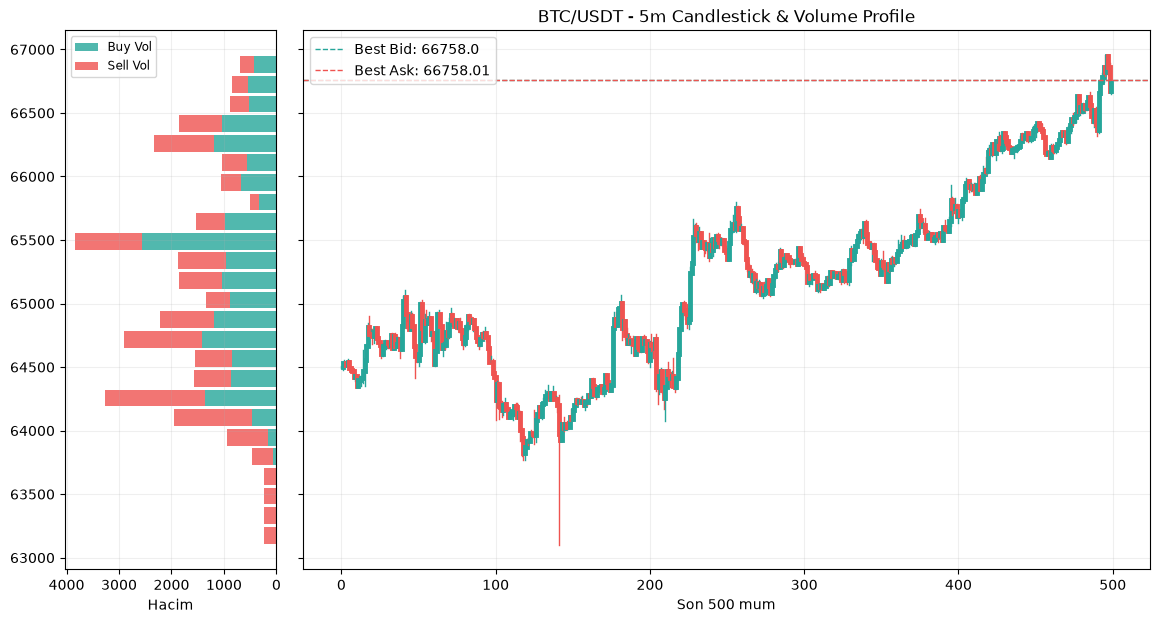

In [63]:
# CCXT sanity check + volume profile
# Bu hucre artik var olan klines_raw'i kullanir; ticker/order-book fail olsa bile OHLCV plot bozulmaz.

import matplotlib.pyplot as plt

try:
    exchange = make_ccxt_exchange()
except Exception as exc:
    exchange = None
    print("CCXT exchange olusturulamadi:", type(exc).__name__, str(exc)[:500])

best_bid = best_ask = last_price = None
if exchange is not None:
    try:
        ticker = load_ccxt_ticker(CCXT_SYMBOL, exchange=exchange)
        best_bid = ticker.get("bid")
        best_ask = ticker.get("ask")
        last_price = ticker.get("last")
    except Exception as exc:
        print("Ticker cekilemedi, OHLCV plot yine devam edecek:", type(exc).__name__, str(exc)[:500])
        try:
            ob = exchange.fetch_order_book(CCXT_SYMBOL, limit=5)
            best_bid = ob["bids"][0][0] if ob.get("bids") else None
            best_ask = ob["asks"][0][0] if ob.get("asks") else None
            last_price = features["close"].iloc[-1] if "features" in globals() and not features.empty else None
        except Exception as ob_exc:
            print("Order book fallback de cekilemedi:", type(ob_exc).__name__, str(ob_exc)[:300])

print(f"{CCXT_SYMBOL} icin CCXT/Notebook verileri")
print("\n--- CANLI/SON BILGI ---")
print(f"Son Fiyat : {last_price}")
print(f"Best Bid  : {best_bid}")
print(f"Best Ask  : {best_ask}")
if best_bid is not None and best_ask is not None:
    print(f"Spread    : {round(best_ask - best_bid, 4)}")
print("-------------------\n")

try:
    if "klines_raw" in globals() and not klines_raw.empty:
        vp_source = klines_raw.copy()
        print(f"Mevcut klines_raw kullaniliyor: {vp_source.shape}")
    elif exchange is not None:
        vp_source = load_ccxt_ohlcv(CCXT_SYMBOL, timeframe=CCXT_TIMEFRAME, limit=CCXT_LIMIT, exchange=exchange)
        print(f"CCXT OHLCV yeniden cekildi: {vp_source.shape}")
    else:
        raise RuntimeError("klines_raw yok ve CCXT exchange olusmadi.")

    vp_df = vp_source.reset_index()
    rename_map = {
        "open_time": "Datetime",
        "timestamp": "Datetime",
        "index": "Datetime",
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume",
    }
    vp_df = vp_df.rename(columns=rename_map)
    for col in ["Open", "High", "Low", "Close", "Volume"]:
        vp_df[col] = pd.to_numeric(vp_df[col], errors="coerce")
    vp_df = vp_df.dropna(subset=["Open", "High", "Low", "Close", "Volume"]).tail(CCXT_LIMIT)

    vp_df["Buy_Vol"] = np.where(vp_df["Close"] >= vp_df["Open"], vp_df["Volume"], 0.0)
    vp_df["Sell_Vol"] = np.where(vp_df["Close"] < vp_df["Open"], vp_df["Volume"], 0.0)

    bins = 25
    price_min = vp_df["Low"].min()
    price_max = vp_df["High"].max()
    price_bins = np.linspace(price_min, price_max, bins + 1)
    buy_profile = np.zeros(bins)
    sell_profile = np.zeros(bins)

    for _, row in vp_df.iterrows():
        bin_indices = np.where((price_bins[:-1] <= row["High"]) & (price_bins[1:] >= row["Low"]))[0]
        if len(bin_indices) > 0:
            buy_profile[bin_indices] += row["Buy_Vol"] / len(bin_indices)
            sell_profile[bin_indices] += row["Sell_Vol"] / len(bin_indices)

    bin_centers = (price_bins[:-1] + price_bins[1:]) / 2
    bin_height = (price_bins[1] - price_bins[0]) * 0.85

    fig, (ax_vp, ax_candle) = plt.subplots(
        1, 2, figsize=(14, 7), sharey=True,
        gridspec_kw={"width_ratios": [1, 4], "wspace": 0.05},
    )

    ax_vp.barh(bin_centers, buy_profile, height=bin_height, color="#26a69a", alpha=0.8, label="Buy Vol")
    ax_vp.barh(bin_centers, sell_profile, height=bin_height, left=buy_profile, color="#ef5350", alpha=0.8, label="Sell Vol")
    ax_vp.invert_xaxis()
    ax_vp.set_xlabel("Hacim")
    ax_vp.legend(loc="upper left", fontsize="small")
    ax_vp.grid(True, alpha=0.2)

    for i in range(len(vp_df)):
        color = "#26a69a" if vp_df["Close"].iloc[i] >= vp_df["Open"].iloc[i] else "#ef5350"
        ax_candle.plot([i, i], [vp_df["Low"].iloc[i], vp_df["High"].iloc[i]], color=color, linewidth=1)
        ax_candle.plot([i, i], [vp_df["Open"].iloc[i], vp_df["Close"].iloc[i]], color=color, linewidth=3.5)

    if best_bid is not None:
        ax_candle.axhline(best_bid, color="#26a69a", linestyle="--", linewidth=1, label=f"Best Bid: {best_bid}")
    if best_ask is not None:
        ax_candle.axhline(best_ask, color="#ef5350", linestyle="--", linewidth=1, label=f"Best Ask: {best_ask}")

    ax_candle.set_title(f"{CCXT_SYMBOL} - {CCXT_TIMEFRAME} Candlestick & Volume Profile")
    ax_candle.set_xlabel(f"Son {len(vp_df)} mum")
    ax_candle.legend(loc="upper left")
    ax_candle.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Volume profile calismadi:", type(exc).__name__, str(exc)[:900])
    print("Ustteki veri hucrelerinde klines_raw dolu mu kontrol et.")
